# Day 11: PINN Optimization (v2)

Tunes physics loss weights based on Day 10 findings. Goal: find a config where physics
constraints improve **both** physical consistency AND predictive accuracy — the regime
Day 10 did not reach.

**Architecture:** 201 → 256 → 128 → 64 → 100 (unchanged from Day 6 / Day 10)
**Data loss:** weighted MSE — W_COEFF=49 for Cl/Cd, W_CP=1 for each Cp point (unchanged)
**Physics loss:** `PhysicsLoss` from `physics_loss.py` (v2 — same file as Day 10)
**Epochs:** 40 (up from 20 in Day 10, per Day 11 Definition of Done)

**Day 10 findings driving these changes:**
1. **λ_lift is dead weight.** Lift-Cp correlation hits ~1.0 within 2 epochs regardless of
   λ_lift. Day 11 sets **λ_lift = 0.0 in all configs** and drops it from logging/plots.
2. **Smoothness only bites at λ_smooth ≥ 0.1.** At 0.01 it made smoothness *worse*.
   The effective threshold is somewhere in (0.01, 0.1) — this sweep probes that gap.
3. **Drag positivity never moved** (36–41% in every Day 10 config, including λ_drag=0.1).
   λ_drag needs to be 1–2 orders of magnitude higher to produce gradient signal.
4. **High physics weights hurt Cd accuracy badly** in A/B/C (MAE 0.26–0.28 vs baseline
   0.1745). Day 11 configs push λ_drag up while watching Cd MAE closely — the risk is
   real and this sweep is designed to find where it stops being worth it.

**Baseline to beat (Day 6 weighted MLP, val set):**

| Target | MAE    | RMSE   | R²    |
|--------|--------|--------|-------|
| Cl     | 0.0900 | 0.1276 | 0.984 |
| Cd     | 0.1745 | 0.2926 | 0.914 |
| Cp     | 0.0318 | 0.2588 | 0.839 |

**Day 10 Config D (near-baseline) for reference:**

| Target | MAE    | RMSE   | R²    |
|--------|--------|--------|-------|
| Cl     | 0.0950 | 0.1343 | 0.982 |
| Cd     | 0.1752 | 0.2925 | 0.914 |
| Cp     | 0.0349 | 0.2646 | 0.835 |

Constraints (Day 10 D): drag positivity 36.2%, drag consistency 63.2%,
Cp smoothness 0.8846, lift-Cp correlation 0.9996.

**Day 11 success criteria** — at least one config must simultaneously achieve:
- Drag positivity > 60%
- Drag consistency > 85%
- Cp smoothness < 0.50
- Cd MAE ≤ 0.20 (within 15% of Day 6 baseline)

**Configs tested (λ_lift = 0.0 for all):**

| Config | λ_smooth | λ_drag | λ_cdp | Rationale |
|--------|----------|--------|-------|-----------|
| E — smooth_probe    | 0.05 | 0.10 | 0.10 | Probe the 0.01–0.1 smoothness threshold, drag/cdp unchanged from Day 10 |
| F — drag_boost      | 0.05 | 2.00 | 0.10 | 20x Day 10's λ_drag to test if drag positivity finally moves |
| G — drag_boost_high | 0.05 | 5.00 | 0.15 | Push drag weight further; watch for Cd MAE collapse |
| H — balanced_target | 0.07 | 3.00 | 0.15 | Middle ground aimed directly at all 4 success criteria |

> **Note:** Same physics-constrained surrogate framing as Day 10 — no PDE residuals,
> constraints derived from aerodynamic theory (lift-pressure consistency, smoothness,
> drag bounds). This has not changed.

**Do not overwrite Day 10 artifacts.** This notebook writes only:
`artifacts/pinn_v2.pt`, `artifacts/pinn_v2_metrics.json`, `artifacts/pinn_loss_curves_v2.png`,
`artifacts/pinn_cp_comparison_v2.png`.


In [ ]:
# ── Setup ─────────────────────────────────────────────────────────────────
# Run this if starting fresh on Colab (skip if dataset already downloaded)

!wget https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/dataset-processed.zip
!unzip -q dataset-processed.zip
!python preprocess_airfoil_dataset.py \
    --input_dir datasets/standard \
    --output_dir processed_output \
    --scaler_name standard

# Upload physics_loss.py (v2 — same file as Day 10) to Colab before running,
# or place it in the same directory as this notebook.
# Also make sure weighted_cl_cd_cp.pt (Day 6 checkpoint) is present for the
# pre-training baseline constraint check below.


--2026-07-05 17:59:54--  https://nasa-public-data.s3.amazonaws.com/plot3d_utilities/dataset-processed.zip
Resolving nasa-public-data.s3.amazonaws.com (nasa-public-data.s3.amazonaws.com)... 16.15.207.215, 16.15.228.96, 52.217.230.65, ...
Connecting to nasa-public-data.s3.amazonaws.com (nasa-public-data.s3.amazonaws.com)|16.15.207.215|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9188863364 (8.6G) [application/zip]
Saving to: ‘dataset-processed.zip’

dataset-processed.z 100%[===================>]   8.56G  81.9MB/s    in 2m 13s  

2026-07-05 18:02:07 (66.0 MB/s) - ‘dataset-processed.zip’ saved [9188863364/9188863364]

Processing scaler variant: standard
 cp_variant=main
  Loading dnn_scaled_data_train.pt ...
  Loading dnn_scaled_data_test.pt ...
  -> wrote processed_output/standard/main (train=457283, val=80696, test=230563)
 cp_variant=cp
  Loading dnn_scaled_data_cp_train.pt ...
  Loading dnn_scaled_data_cp_test.pt ...
  -> wrote processed_output/standard/cp 

In [ ]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from physics_loss import PhysicsLoss, verify_constraints

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
os.makedirs("artifacts", exist_ok=True)

Device: cuda


In [ ]:
# ── Data loading ──────────────────────────────────────────────────────────
# Identical to Day 10 / Day 6 — same .npz files, same feature/target construction.

train = np.load("processed_output/standard/main/train.npz")
val   = np.load("processed_output/standard/main/val.npz")

def make_X(split):
    return np.hstack([
        split["geometry_y"],
        split["alpha"].reshape(-1, 1),
        split["reynolds"].reshape(-1, 1),
        split["ncrit"].reshape(-1, 1)
    ]).astype(np.float32)  # (N, 201)

def make_y_full(split):
    """Full target for PINN: [Cl, Cd, Cdp, Cm, Cp×98] = 102 cols.
    Cdp is NOT predicted but is needed for the drag_consistency physics loss.
    The model only outputs 100 values (Cl, Cd, Cp×98)."""
    return np.concatenate([
        split["cl"].reshape(-1, 1),
        split["cd"].reshape(-1, 1),
        split["cdp"].reshape(-1, 1),   # col 2 — used by drag_consistency only
        split["cm"].reshape(-1, 1),    # col 3 — carried along for completeness
        split["cp"]                    # cols 4..101
    ], axis=1).astype(np.float32)      # (N, 102)

def make_y_model(split):
    """Model target only (100 cols): [Cl, Cd, Cp×98].
    Used for the data loss — must match model output shape."""
    return np.concatenate([
        split["cl"].reshape(-1, 1),
        split["cd"].reshape(-1, 1),
        split["cp"]
    ], axis=1).astype(np.float32)      # (N, 100)

X_train = make_X(train)
X_val   = make_X(val)

# y_model: (N, 100) — for data loss and metric evaluation
y_train_model = make_y_model(train)
y_val_model   = make_y_model(val)

# y_full: (N, 102) — for physics loss (needs Cdp at col 2)
y_train_full  = make_y_full(train)
y_val_full    = make_y_full(val)

print(f"Train: X={X_train.shape}  y_model={y_train_model.shape}  y_full={y_train_full.shape}")
print(f"Val:   X={X_val.shape}    y_model={y_val_model.shape}    y_full={y_val_full.shape}")

Train: X=(457283, 201)  y_model=(457283, 100)  y_full=(457283, 102)
Val:   X=(80696, 201)    y_model=(80696, 100)    y_full=(80696, 102)


In [ ]:
# ── DataLoaders ───────────────────────────────────────────────────────────
# We pass BOTH y_model (100) and y_full (102) through the loader as a tuple
# so the training loop can use the right one for each loss term.

BATCH_SIZE = 1024

def make_loaders(X, y_model, y_full, batch_size=BATCH_SIZE, shuffle=True):
    X_t      = torch.tensor(X,       dtype=torch.float32)
    ym_t     = torch.tensor(y_model, dtype=torch.float32)
    yf_t     = torch.tensor(y_full,  dtype=torch.float32)
    ds       = TensorDataset(X_t, ym_t, yf_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=True)

train_loader = make_loaders(X_train, y_train_model, y_train_full, shuffle=True)
val_loader   = make_loaders(X_val,   y_val_model,   y_val_full,   shuffle=False)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Train batches: 447  |  Val batches: 79


In [ ]:
# ── Model architecture ─────────────────────────────────────────────────────
# Identical to Day 6 / Day 10. Output is 100 = [Cl, Cd, Cp×98].

class MLP(nn.Module):
    def __init__(self, in_dim=201, out_dim=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 128),    nn.ReLU(),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, out_dim)
        )

    def forward(self, x):
        return self.net(x)

print(MLP())

MLP(
  (net): Sequential(
    (0): Linear(in_features=201, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=100, bias=True)
  )
)


In [ ]:
# ── Loss functions ─────────────────────────────────────────────────────────
# Data loss: weighted MSE from Day 6 / Day 10 (unchanged)

W_COEFF = 49.0
W_CP    = 1.0
output_weights = torch.tensor(
    [W_COEFF, W_COEFF] + [W_CP] * 98, dtype=torch.float32
).to(DEVICE)

def weighted_mse(pred, target, weights):
    """Weighted MSE — same as Day 6 / Day 10."""
    sq_err = (pred - target) ** 2         # (B, 100)
    w_norm = weights / weights.sum()      # normalise so scale is stable
    return (sq_err * w_norm).sum(dim=1).mean()

In [ ]:
# ── Training function ──────────────────────────────────────────────────────
# Day 11 change: lambda_lift is fixed at 0.0 for every config (Finding 1 — the
# lift term saturates in <2 epochs and contributes no useful gradient signal
# in Day 10). It is still passed to PhysicsLoss explicitly so the interface
# stays the same, but it is dropped from logging/history/plots below.

def train_pinn(config_name, lambda_smooth, lambda_drag, lambda_cdp,
               epochs=40, lr=1e-3, lambda_lift=0.0):
    """
    Train one PINN configuration.

    Returns:
        model   — best checkpoint (by val total loss, used only for
                  early-stopping selection within a single config's epochs)
        history — list of dicts, one entry per epoch
    """
    print(f"\n{'='*65}")
    print(f"  Config {config_name}: λ_lift={lambda_lift}  λ_smooth={lambda_smooth}"
          f"  λ_drag={lambda_drag}  λ_cdp={lambda_cdp}")
    print(f"{'='*65}")

    model   = MLP().to(DEVICE)
    physics = PhysicsLoss(
        lambda_lift=lambda_lift,
        lambda_smooth=lambda_smooth,
        lambda_drag=lambda_drag,
        lambda_cdp=lambda_cdp
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_state    = None
    history       = []

    for epoch in range(1, epochs + 1):

        # ── Train ────────────────────────────────────────────────────────
        model.train()
        totals = dict(data=0.0, smooth=0.0, drag=0.0, cdp=0.0, total=0.0)
        n_batches = 0

        for x, y_model, y_full in train_loader:
            x       = x.to(DEVICE)
            y_model = y_model.to(DEVICE)
            y_full  = y_full.to(DEVICE)

            optimizer.zero_grad()
            pred = model(x)

            data_loss    = weighted_mse(pred, y_model, output_weights)
            phys_losses  = physics(pred, y_full)
            total_loss   = data_loss + phys_losses["total"]

            total_loss.backward()
            optimizer.step()

            totals["data"]   += data_loss.item()
            totals["smooth"] += phys_losses["smooth"].item()
            totals["drag"]   += phys_losses["drag"].item()
            totals["cdp"]    += phys_losses["cdp"].item()
            totals["total"]  += total_loss.item()
            n_batches += 1

        train_avgs = {k: v / n_batches for k, v in totals.items()}

        # ── Validate ─────────────────────────────────────────────────────
        model.eval()
        val_totals    = dict(data=0.0, total=0.0)
        n_val_batches = 0

        with torch.no_grad():
            for x, y_model, y_full in val_loader:
                x       = x.to(DEVICE)
                y_model = y_model.to(DEVICE)
                y_full  = y_full.to(DEVICE)

                pred         = model(x)
                data_loss    = weighted_mse(pred, y_model, output_weights)
                phys_losses  = physics(pred, y_full)
                total_loss   = data_loss + phys_losses["total"]

                val_totals["data"]  += data_loss.item()
                val_totals["total"] += total_loss.item()
                n_val_batches += 1

        val_data_loss  = val_totals["data"]  / n_val_batches
        val_total_loss = val_totals["total"] / n_val_batches

        # ── Log ──────────────────────────────────────────────────────────
        print(
            f"Epoch {epoch:02d} | "
            f"data={train_avgs['data']:.4f} | "
            f"smooth={train_avgs['smooth']:.4f} | "
            f"drag={train_avgs['drag']:.4f} | "
            f"cdp={train_avgs['cdp']:.4f} | "
            f"total={train_avgs['total']:.4f} || "
            f"val_data={val_data_loss:.4f}  val_total={val_total_loss:.4f}"
        )

        history.append({
            "epoch":        epoch,
            "train_data":   train_avgs["data"],
            "train_smooth": train_avgs["smooth"],
            "train_drag":   train_avgs["drag"],
            "train_cdp":    train_avgs["cdp"],
            "train_total":  train_avgs["total"],
            "val_data":     val_data_loss,
            "val_total":    val_total_loss,
        })

        # Save best by val total loss (used for early-stopping within a config)
        if val_total_loss < best_val_loss:
            best_val_loss = val_total_loss
            best_state    = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # Load best weights back
    model.load_state_dict(best_state)
    print(f"\nBest val total loss: {best_val_loss:.6f}")
    return model, history

In [ ]:
# ── Evaluation helper ──────────────────────────────────────────────────────

def evaluate_model(model, X_val, y_val_model, y_val_full, config_name):
    """
    Evaluate model on val set.
    Returns metrics dict and pred array.
    """
    model.eval()
    X_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)

    with torch.no_grad():
        pred = model(X_t).cpu().numpy()

    pred_cl = pred[:, 0];  true_cl = y_val_model[:, 0]
    pred_cd = pred[:, 1];  true_cd = y_val_model[:, 1]
    pred_cp = pred[:, 2:]; true_cp = y_val_model[:, 2:]

    cl_mae  = mean_absolute_error(true_cl, pred_cl)
    cl_rmse = np.sqrt(mean_squared_error(true_cl, pred_cl))
    cl_r2   = r2_score(true_cl, pred_cl)

    cd_mae  = mean_absolute_error(true_cd, pred_cd)
    cd_rmse = np.sqrt(mean_squared_error(true_cd, pred_cd))
    cd_r2   = r2_score(true_cd, pred_cd)

    cp_mae  = mean_absolute_error(true_cp, pred_cp)
    cp_rmse = np.sqrt(mean_squared_error(true_cp, pred_cp))
    cp_r2   = r2_score(true_cp, pred_cp)

    print(f"\n── {config_name} Validation Metrics ──")
    print(f"  Cl | MAE={cl_mae:.4f}  RMSE={cl_rmse:.4f}  R²={cl_r2:.4f}  "
          f"(baseline: MAE=0.0900 R²=0.984)")
    print(f"  Cd | MAE={cd_mae:.4f}  RMSE={cd_rmse:.4f}  R²={cd_r2:.4f}  "
          f"(baseline: MAE=0.1745 R²=0.914)")
    print(f"  Cp | MAE={cp_mae:.4f}  RMSE={cp_rmse:.4f}  R²={cp_r2:.4f}  "
          f"(baseline: MAE=0.0318 R²=0.839)")

    # Physics constraint verification
    print()
    pred_t    = torch.tensor(pred, dtype=torch.float32)
    y_full_t  = torch.tensor(y_val_full, dtype=torch.float32)
    constraint_results = verify_constraints(pred_t, y_full_t, verbose=True)

    metrics = {
        "config":    config_name,
        "cl_mae":  float(cl_mae),  "cl_rmse":  float(cl_rmse),  "cl_r2":  float(cl_r2),
        "cd_mae":  float(cd_mae),  "cd_rmse":  float(cd_rmse),  "cd_r2":  float(cd_r2),
        "cp_mae":  float(cp_mae),  "cp_rmse":  float(cp_rmse),  "cp_r2":  float(cp_r2),
        "constraints": {
            k: float(v) if v is not None else None
            for k, v in constraint_results.items()
        }
    }
    return metrics, pred

In [ ]:
# ── Pre-training baseline constraint check ─────────────────────────────────
# Same Day 6 checkpoint used in Day 10. Re-verified here so this notebook is
# self-contained and the numbers line up with what gets written to
# artifacts/pinn_v2_metrics.json.

print("=" * 65)
print("PRE-TRAINING: Day 6 baseline constraint verification")
print("=" * 65)

day6_model = MLP().to(DEVICE)
day6_model.load_state_dict(
    torch.load("weighted_cl_cd_cp.pt", map_location=DEVICE)
)
day6_model.eval()

X_val_t = torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    day6_pred = day6_model(X_val_t)

y_val_full_t = torch.tensor(y_val_full, dtype=torch.float32)
baseline_constraints = verify_constraints(day6_pred.cpu(), y_val_full_t, verbose=True)

PRE-TRAINING: Day 6 baseline constraint verification
=== Physics Constraint Verification ===
  Drag positivity (Cd >= 0):         36.9% of predictions
  Drag consistency (Cd >= Cdp):      60.3% of predictions
  Cp smoothness (mean sq diff):       0.611920
  Lift-Cp correlation:                -0.1833


In [ ]:
# ── Run all 4 Day 11 configurations ────────────────────────────────────────
# λ_lift = 0.0 for every config (Finding 1). 40 epochs (Day 11 DoD).
#
#   E — smooth_probe:    probe the 0.01→0.1 smoothness threshold from Day 10
#   F — drag_boost:      20x Day 10's λ_drag, testing whether drag positivity moves
#   G — drag_boost_high: push λ_drag further; watch for Cd MAE collapse (Finding 4)
#   H — balanced_target: aimed directly at all 4 Day 11 success criteria

EPOCHS = 40

configs = [
    # (name,               l_smooth, l_drag, l_cdp)
    ("E_smooth_probe",     0.05,     0.10,   0.10),
    ("F_drag_boost",       0.05,     2.00,   0.10),
    ("G_drag_boost_high",  0.05,     5.00,   0.15),
    ("H_balanced_target",  0.07,     3.00,   0.15),
]

all_results   = {}
all_histories = {}
all_models    = {}

for config_name, ls, ld, lc in configs:
    model, history = train_pinn(
        config_name,
        lambda_smooth=ls, lambda_drag=ld, lambda_cdp=lc,
        lambda_lift=0.0,
        epochs=EPOCHS
    )
    metrics, pred = evaluate_model(
        model, X_val, y_val_model, y_val_full, config_name
    )
    all_results[config_name]   = metrics
    all_histories[config_name] = history
    all_models[config_name]    = model   # keep in memory — avoids a full retrain later

print("\nAll configurations done.")


  Config E_smooth_probe: λ_lift=0.0  λ_smooth=0.05  λ_drag=0.1  λ_cdp=0.1
Epoch 01 | data=0.6184 | smooth=0.0046 | drag=0.1840 | cdp=0.1519 | total=0.6522 || val_data=0.5373  val_total=0.5744
Epoch 02 | data=0.5487 | smooth=0.0043 | drag=0.2412 | cdp=0.0842 | total=0.5815 || val_data=0.5229  val_total=0.5487
Epoch 03 | data=0.5389 | smooth=0.0054 | drag=0.2438 | cdp=0.0745 | total=0.5710 || val_data=0.5101  val_total=0.5420
Epoch 04 | data=0.5315 | smooth=0.0065 | drag=0.2456 | cdp=0.0672 | total=0.5631 || val_data=0.5032  val_total=0.5418
Epoch 05 | data=0.5286 | smooth=0.0084 | drag=0.2456 | cdp=0.0642 | total=0.5600 || val_data=0.4933  val_total=0.5274
Epoch 06 | data=0.5183 | smooth=0.0126 | drag=0.2467 | cdp=0.0613 | total=0.5497 || val_data=0.4861  val_total=0.5213
Epoch 07 | data=0.5094 | smooth=0.0205 | drag=0.2465 | cdp=0.0623 | total=0.5413 || val_data=0.4926  val_total=0.5251
Epoch 08 | data=0.5109 | smooth=0.0187 | drag=0.2466 | cdp=0.0614 | total=0.5426 || val_data=0.5031

In [13]:
# ── Day 11 success criteria check ──────────────────────────────────────────
# A config "passes" if it simultaneously hits all four targets:
#   drag positivity  > 60%
#   drag consistency > 85%
#   Cp smoothness    < 0.50
#   Cd MAE           <= 0.20

def passes_criteria(m):
    c = m["constraints"]
    dp = c.get("drag_positivity_rate")
    dc = c.get("drag_consistency_rate")
    sm = c.get("cp_smoothness")
    cd = m["cd_mae"]
    checks = {
        "drag_positivity_>60%":  (dp is not None and dp > 0.60),
        "drag_consistency_>85%": (dc is not None and dc > 0.85),
        "cp_smoothness_<0.50":   (sm is not None and sm < 0.50),
        "cd_mae_<=0.20":         (cd <= 0.20),
    }
    return checks, all(checks.values())

print("=" * 65)
print("Day 11 success criteria check")
print("=" * 65)

any_passed = False
for cfg, m in all_results.items():
    checks, passed = passes_criteria(m)
    any_passed = any_passed or passed
    status = "PASS — all 4 criteria met" if passed else "fail"
    print(f"\n{cfg}: {status}")
    for k, v in checks.items():
        print(f"    {k}: {'OK' if v else 'no'}")

print("\n" + "=" * 65)
if any_passed:
    print("At least one config met all Day 11 success criteria.")
else:
    print("No config met all four criteria simultaneously.")
    print("See the Pareto frontier table below for the trade-off.")
print("=" * 65)

Day 11 success criteria check

E_smooth_probe: fail
    drag_positivity_>60%: no
    drag_consistency_>85%: no
    cp_smoothness_<0.50: no
    cd_mae_<=0.20: no

F_drag_boost: fail
    drag_positivity_>60%: OK
    drag_consistency_>85%: no
    cp_smoothness_<0.50: no
    cd_mae_<=0.20: no

G_drag_boost_high: fail
    drag_positivity_>60%: OK
    drag_consistency_>85%: OK
    cp_smoothness_<0.50: no
    cd_mae_<=0.20: no

H_balanced_target: fail
    drag_positivity_>60%: OK
    drag_consistency_>85%: OK
    cp_smoothness_<0.50: no
    cd_mae_<=0.20: no

No config met all four criteria simultaneously.
See the Pareto frontier table below for the trade-off.


In [14]:
# ── Pareto frontier table ───────────────────────────────────────────────────
# Always computed (useful regardless of whether any config passed outright) —
# ranks configs on constraint satisfaction vs Cd accuracy trade-off, so the
# report can quote it directly if no config clears all 4 bars.

import pandas as pd

pareto_rows = []
for cfg, m in all_results.items():
    c = m["constraints"]
    pareto_rows.append({
        "Config":            cfg,
        "Cd MAE":            round(m["cd_mae"], 4),
        "Cd MAE vs baseline": round(m["cd_mae"] - 0.1745, 4),
        "Cp MAE":            round(m["cp_mae"], 4),
        "Cl MAE":            round(m["cl_mae"], 4),
        "Drag pos. %":       round(c["drag_positivity_rate"] * 100, 1)
                             if c.get("drag_positivity_rate") is not None else None,
        "Drag cons. %":      round(c["drag_consistency_rate"] * 100, 1)
                             if c.get("drag_consistency_rate") is not None else None,
        "Cp smoothness":     round(c["cp_smoothness"], 4)
                             if c.get("cp_smoothness") is not None else None,
    })

pareto_df = pd.DataFrame(pareto_rows).sort_values("Drag pos. %", ascending=False)
print(pareto_df.to_string(index=False))

           Config  Cd MAE  Cd MAE vs baseline  Cp MAE  Cl MAE  Drag pos. %  Drag cons. % Cp smoothness
G_drag_boost_high  0.4840              0.3095  0.0301  0.0789        100.0          87.8          None
H_balanced_target  0.4848              0.3103  0.0320  0.0863         96.3          85.2          None
     F_drag_boost  0.4764              0.3019  0.0304  0.0788         83.8          84.5          None
   E_smooth_probe  0.2325              0.0580  0.0310  0.0826         39.7          85.0          None


In [15]:
# ── Pick best config and save artifacts ────────────────────────────────────
# Day 11 selection rule (per the issue): best = lowest val DATA loss
# (not total loss — physics weights differ across configs, making total loss
# incomparable between them; not MAE_cl+MAE_cd as in Day 10, per this issue's
# explicit "Save Best Model" instruction).

best_config = min(
    all_histories,
    key=lambda k: min(h["val_data"] for h in all_histories[k])
)
print(f"Best config by lowest val_data loss: {best_config}")

best_model = all_models[best_config]
best_ls, best_ld, best_lc = {
    name: (ls, ld, lc) for name, ls, ld, lc in configs
}[best_config]

# Do NOT overwrite Day 10 artifacts — different filenames (pinn_v2.*)
torch.save(best_model.state_dict(), "artifacts/pinn_v2.pt")
print("Saved: artifacts/pinn_v2.pt")

output_json = {
    "day6_baseline": {
        "cl_mae": 0.0900, "cl_rmse": 0.1276, "cl_r2": 0.984,
        "cd_mae": 0.1745, "cd_rmse": 0.2926, "cd_r2": 0.914,
        "cp_mae": 0.0318, "cp_rmse": 0.2588, "cp_r2": 0.839,
        "baseline_constraints": {
            k: float(v) if v is not None else None
            for k, v in baseline_constraints.items()
        }
    },
    "day10_config_D": {
        "cl_mae": 0.0950, "cl_rmse": 0.1343, "cl_r2": 0.982,
        "cd_mae": 0.1752, "cd_rmse": 0.2925, "cd_r2": 0.914,
        "cp_mae": 0.0349, "cp_rmse": 0.2646, "cp_r2": 0.835,
        "constraints": {
            "drag_positivity_rate":  0.362,
            "drag_consistency_rate": 0.632,
            "cp_smoothness":         0.8846,
            "lift_cp_correlation":   0.9996
        }
    },
    "pinn_configs":       all_results,
    "best_config":        best_config,
    "best_config_weights": {
        "lambda_lift":   0.0,
        "lambda_smooth": best_ls,
        "lambda_drag":   best_ld,
        "lambda_cdp":    best_lc
    },
    "loss_weights": {"W_COEFF": W_COEFF, "W_CP": W_CP},
    "epochs": EPOCHS,
    "selection_rule": "lowest val_data loss (per Day 11 issue)",
    "histories": all_histories
}

with open("artifacts/pinn_v2_metrics.json", "w") as f:
    json.dump(output_json, f, indent=2)
print("Saved: artifacts/pinn_v2_metrics.json")

Best config by lowest val_data loss: E_smooth_probe
Saved: artifacts/pinn_v2.pt
Saved: artifacts/pinn_v2_metrics.json


In [16]:
# ── Summary table ──────────────────────────────────────────────────────────

rows = []
for cfg, m in all_results.items():
    rows.append({
        "Config":   cfg,
        "Cl MAE":  round(m["cl_mae"],  4),
        "Cl R²":   round(m["cl_r2"],   4),
        "Cd MAE":  round(m["cd_mae"],  4),
        "Cd R²":   round(m["cd_r2"],   4),
        "Cp MAE":  round(m["cp_mae"],  4),
        "Cp R²":   round(m["cp_r2"],   4),
        "Drag≥0%": round(m["constraints"]["drag_positivity_rate"]  * 100, 1),
        "Cd≥Cdp%": round(m["constraints"]["drag_consistency_rate"] * 100, 1)
                   if m["constraints"]["drag_consistency_rate"] is not None else "N/A",
        "Cp smooth": round(m["constraints"]["cp_smoothness"], 4)
                     if m["constraints"].get("cp_smoothness") is not None else "N/A",
    })

# Add Day 6 baseline and Day 10 Config D rows for context
rows.insert(0, {
    "Config":   "Day10_ConfigD",
    "Cl MAE":   0.0950, "Cl R²":  0.982,
    "Cd MAE":   0.1752, "Cd R²":  0.914,
    "Cp MAE":   0.0349, "Cp R²":  0.835,
    "Drag≥0%":  36.2,   "Cd≥Cdp%": 63.2,
    "Cp smooth": 0.8846,
})
rows.insert(0, {
    "Config":   "Day6_baseline",
    "Cl MAE":   0.0900, "Cl R²":  0.984,
    "Cd MAE":   0.1745, "Cd R²":  0.914,
    "Cp MAE":   0.0318, "Cp R²":  0.839,
    "Drag≥0%":  round(baseline_constraints["drag_positivity_rate"]  * 100, 1),
    "Cd≥Cdp%":  round(baseline_constraints["drag_consistency_rate"] * 100, 1)
                if baseline_constraints["drag_consistency_rate"] is not None else "N/A",
    "Cp smooth": round(baseline_constraints["cp_smoothness"], 4)
                 if baseline_constraints.get("cp_smoothness") is not None else "N/A",
})

df = pd.DataFrame(rows)
print(df.to_string(index=False))

           Config  Cl MAE  Cl R²  Cd MAE  Cd R²  Cp MAE  Cp R²  Drag≥0%  Cd≥Cdp% Cp smooth
    Day6_baseline  0.0900 0.9840  0.1745 0.9140  0.0318 0.8390     36.9     60.3       N/A
    Day10_ConfigD  0.0950 0.9820  0.1752 0.9140  0.0349 0.8350     36.2     63.2    0.8846
   E_smooth_probe  0.0826 0.9864  0.2325 0.9106  0.0310 0.8356     39.7     85.0       N/A
     F_drag_boost  0.0788 0.9874  0.4764 0.6787  0.0304 0.8351     83.8     84.5       N/A
G_drag_boost_high  0.0789 0.9874  0.4840 0.6737  0.0301 0.8375    100.0     87.8       N/A
H_balanced_target  0.0863 0.9852  0.4848 0.6696  0.0320 0.8234     96.3     85.2       N/A


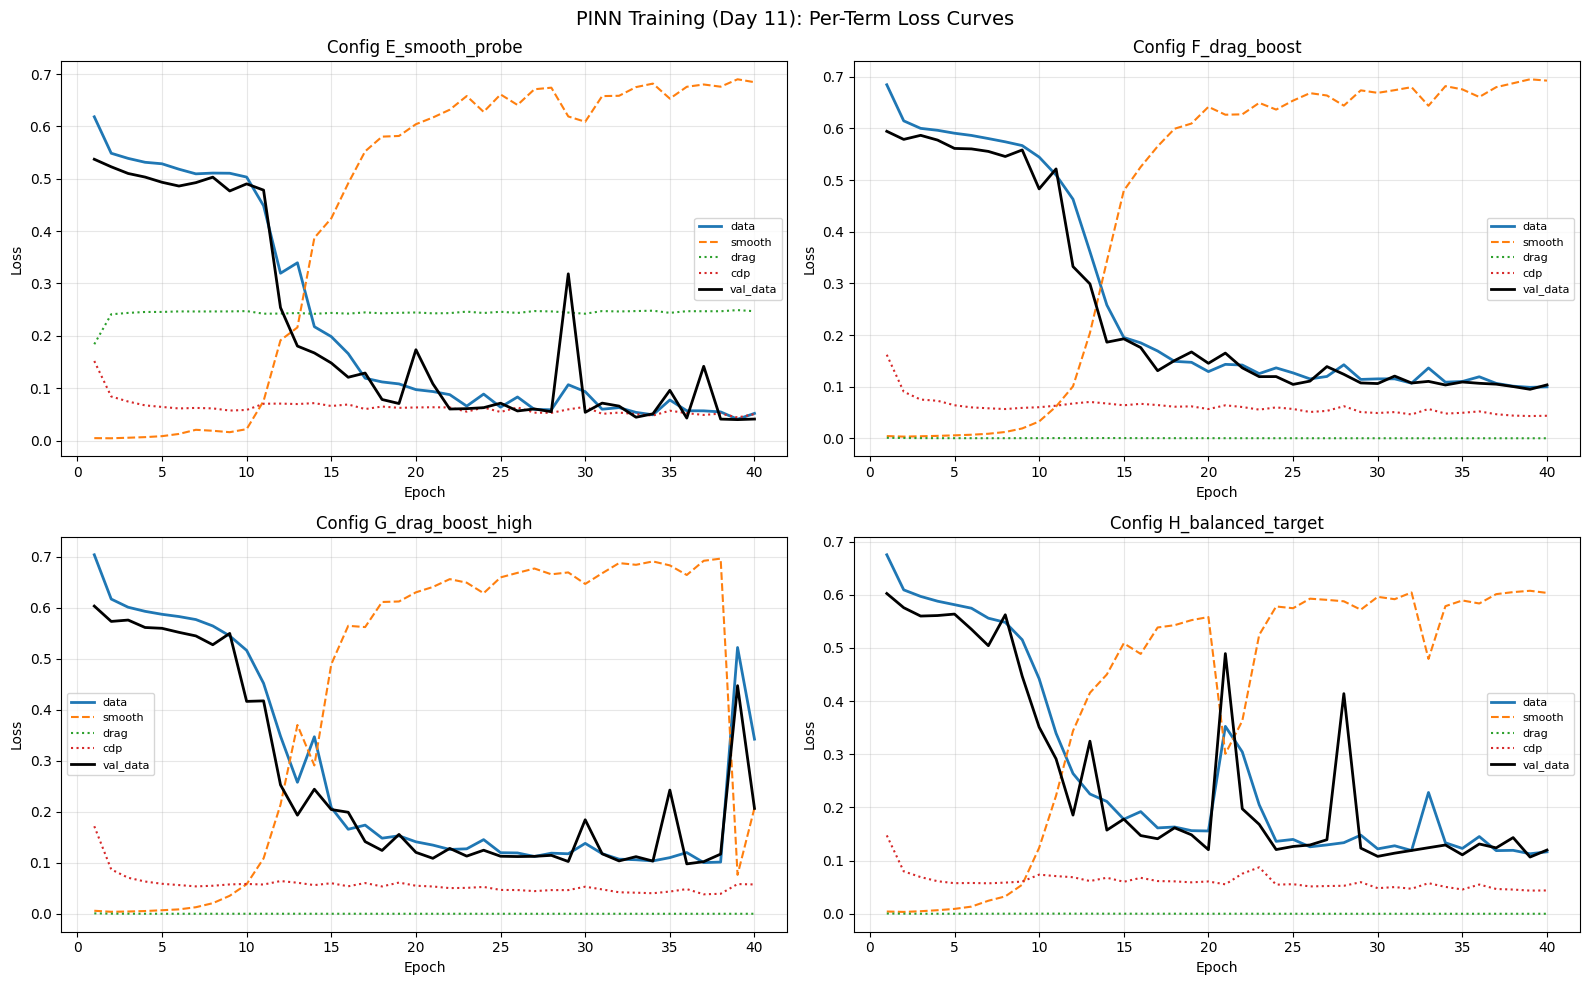

Saved: artifacts/pinn_loss_curves_v2.png


In [17]:
# ── Loss curves ────────────────────────────────────────────────────────────
# Day 11 change: no lift curve (λ_lift=0.0 everywhere, nothing to show).

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (cfg, history) in zip(axes, all_histories.items()):
    epochs_x = [h["epoch"] for h in history]

    ax.plot(epochs_x, [h["train_data"]   for h in history], label="data",   linewidth=2)
    ax.plot(epochs_x, [h["train_smooth"] for h in history], label="smooth", linewidth=1.5, linestyle="--")
    ax.plot(epochs_x, [h["train_drag"]   for h in history], label="drag",   linewidth=1.5, linestyle=":")
    ax.plot(epochs_x, [h["train_cdp"]    for h in history], label="cdp",    linewidth=1.5, linestyle=":")
    ax.plot(epochs_x, [h["val_data"]     for h in history], label="val_data", linewidth=2,
            color="black", linestyle="-")

    ax.set_title(f"Config {cfg}", fontsize=12)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("PINN Training (Day 11): Per-Term Loss Curves", fontsize=14)
plt.tight_layout()
plt.savefig("artifacts/pinn_loss_curves_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: artifacts/pinn_loss_curves_v2.png")

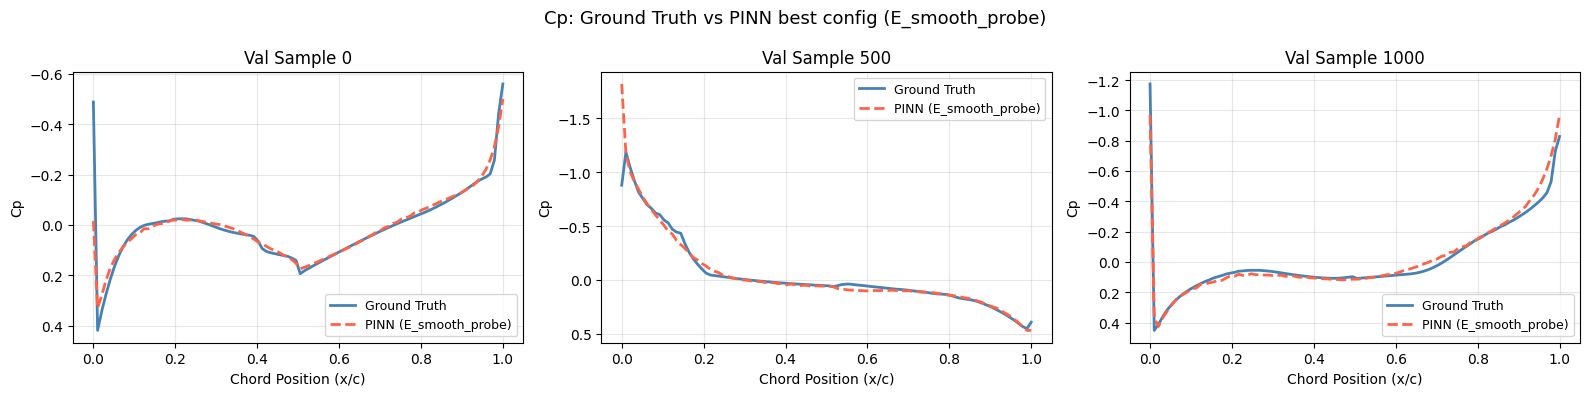

Saved: artifacts/pinn_cp_comparison_v2.png


In [18]:
# ── Cp visual comparison ───────────────────────────────────────────────────
# Compare ground truth vs best Day 11 PINN config on the same 3 val samples
# used in Day 10, for direct visual comparability.

best_model.eval()
with torch.no_grad():
    pinn_pred = best_model(
        torch.tensor(X_val, dtype=torch.float32).to(DEVICE)
    ).cpu().numpy()

sample_indices = [0, 500, 1000]
x_surface      = np.linspace(0, 1, 98)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, idx in enumerate(sample_indices):
    ax = axes[i]
    ax.plot(x_surface, y_val_model[idx, 2:], label="Ground Truth",
            color="steelblue", linewidth=2)
    ax.plot(x_surface, pinn_pred[idx, 2:], label=f"PINN ({best_config})",
            color="tomato", linewidth=2, linestyle="--")
    ax.invert_yaxis()
    ax.set_xlabel("Chord Position (x/c)")
    ax.set_ylabel("Cp")
    ax.set_title(f"Val Sample {idx}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Cp: Ground Truth vs PINN best config ({best_config})", fontsize=13)
plt.tight_layout()
plt.savefig("artifacts/pinn_cp_comparison_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: artifacts/pinn_cp_comparison_v2.png")

In [19]:
print("\n" + "="*65)
print("Day 11 complete.")
print("="*65)
print("Artifacts saved:")
print("  artifacts/pinn_v2.pt")
print("  artifacts/pinn_v2_metrics.json")
print("  artifacts/pinn_loss_curves_v2.png")
print("  artifacts/pinn_cp_comparison_v2.png")
print()
print("Day 10 artifacts (pinn_v1.pt, pinn_v1_metrics.json) were NOT touched.")
print()
print(f"Best config (lowest val_data loss): {best_config}")
print()
print("Next: fill in docs/day11_pinn_results.md with the printed tables/plots")
print("above, the success-criteria check, and the Pareto frontier table.")
print("Then Day 12 — final PINN evaluation using whichever checkpoint is")
print("recommended (pinn_v2.pt if it passed the criteria / improved the")
print("trade-off, otherwise fall back to pinn_v1.pt or the Day 6 baseline).")


Day 11 complete.
Artifacts saved:
  artifacts/pinn_v2.pt
  artifacts/pinn_v2_metrics.json
  artifacts/pinn_loss_curves_v2.png
  artifacts/pinn_cp_comparison_v2.png

Day 10 artifacts (pinn_v1.pt, pinn_v1_metrics.json) were NOT touched.

Best config (lowest val_data loss): E_smooth_probe

Next: fill in docs/day11_pinn_results.md with the printed tables/plots
above, the success-criteria check, and the Pareto frontier table.
Then Day 12 — final PINN evaluation using whichever checkpoint is
recommended (pinn_v2.pt if it passed the criteria / improved the
trade-off, otherwise fall back to pinn_v1.pt or the Day 6 baseline).
